# Preamble

In [33]:
from matplotlib import pyplot as plt # plotting
import math
import sklearn

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared, ConstantKernel, DotProduct, Matern, RationalQuadratic
from sklearn.cluster import KMeans
import optuna

import scipy
from tqdm import tqdm
import numpy as np
import gymnasium as gym
import gym_unbalanced_disk, time

np.random.seed(101)


def rbf(x1,x2,width):
    return np.exp(-0.5* (x1-x2)**2/width)

def demonstrate(full_range,y1,label,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,y1,label=label)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid()
    plt.savefig(f'{name}.png')
    plt.show()
    return

def demonstrate_alternate(part_range, y1,f,var, name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(part_range,y1,label="Data")
    plt.plot(part_range,f,label="Prediction")
    plt.fill_between(part_range,f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid()
    plt.savefig(f'{name}.png')
    plt.show()
    
    return

def quick_plot(full_range,f,var,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,f,label="Prediction")
    plt.fill_between(full_range,f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('f')
    plt.legend()
    plt.grid()
    plt.show()
    return

def quick_plot_alternative(full_range,f,var,index,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,f,label="Prediction")
    plt.fill_between(full_range,f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('f')
    plt.legend()
    plt.grid()
    plt.show()
    return

def state_prep(data, time, order):
        time += 1
        entries = np.min([time,order])
        state = np.zeros((order,2))
        state[(order-entries):order,:] = data[(time-entries):time,:]
        return np.concat((state[:,0].reshape(1,order),state[:,1].reshape(1,order)),axis=1)

def state_prep_loop(data, order):
    states = np.zeros((len(data),2*order))
    for time in range(len(data)): states[time] = state_prep(data, time, order)
    return states

In [15]:
predict_handler = lambda x: (BCM_predict(x,reg_bcm))

def simulate_handler(x, reg_bcm):
    return np.squeeze(BCM_predict(x[None,:],reg_bcm)[0]), np.squeeze(BCM_predict(x[None,:],reg_bcm)[1])


def simulation_IO_model_custom(f, reg, ulist, ylist, na, nb, skip=50):
    
    upast = ulist[skip-nb:skip].tolist() #good initialization
    ypast = ylist[skip-na:skip].tolist()
    Y = ylist[:skip].tolist()
    var = []
    for u in tqdm(ulist[skip:]):
        #print(u)
        x = np.concatenate([upast,ypast],axis=0)
        ypred, v = f(x, reg)
        var.append(v)
        Y.append(ypred)
        upast.append(u)
        upast.pop(0)
        ypast.append(ypred)
        ypast.pop(0)
    return np.array(Y), np.concat((np.zeros(max(na,nb)),np.array(var)))

def create_IO_data(u,y,na,nb):
    X = []
    Y = []
    for k in range(max(na,nb), len(y)):
        X.append(np.concatenate([u[k-nb:k],y[k-na:k]]))
        Y.append(y[k])
    return np.array(X), np.array(Y)

# Bayseian committee machine

In [16]:
def BCM_predict(x22,reg_bcm):

    t_bcm = x22.shape[0]
    prediction_blocks = len(reg_bcm)

    #Initialisation
    f_bcm = np.array(np.zeros([t_bcm, prediction_blocks]))
    f_bcm_run = np.array(np.zeros(t_bcm))
    var_bcm = f_bcm
    precision = np.array(np.zeros([t_bcm, prediction_blocks]))
    precision_run = np.array(np.zeros([t_bcm]))

    #accumulating and combining predictions
    for i in range(prediction_blocks):
        f_bcm[:,i], precision[:,i] = reg_bcm[i].predict(x22,return_std=True)
        
        #sanity checker ignores the results from experts giving NaN or divide by 0 outputs
        if (precision[:,i].all()>0) and (f_bcm[:,i].all() == f_bcm[:,i].all()): 
            precision[:,i] = precision[:,i]**-2
        else: 
            f_bcm[:,i], precision[:,i] = 0, 0
            prediction_blocks += -1             #This accounts for the reduced number of experts for confidence calculations
        
        precision_run = precision_run + precision[:,i]
        f_bcm_run = f_bcm_run + precision[:,i]*f_bcm[:,i]
    
    K22_factor = np.ones(t_bcm)*2

    cov_bcm = ( -(prediction_blocks-1)*(K22_factor) + precision_run)**-1

    var_bcm = cov_bcm
    f_bcm = (cov_bcm*f_bcm_run)

    return f_bcm, var_bcm

def BCM_train(x1,y1,ker_bcm,p_bcm,N,n_restarts_optimizer=10, labels=np.array([False])):
    reg_bcm = np.zeros([p_bcm],dtype='object')
    
    for p in tqdm(range(p_bcm)):
        
        if labels.any():
            x11 = x1[labels==p]
            y11 = y1[labels==p]
        else:
            x11 = x1[int(p*N/p_bcm):int((p+1)*N/p_bcm)]
            y11 = y1[int(p*N/p_bcm):int((p+1)*N/p_bcm)]
        
        reg_bcm[p] = GaussianProcessRegressor(ker_bcm,alpha=10**-6, n_restarts_optimizer=n_restarts_optimizer, normalize_y=True) #a=)
        reg_bcm[p].fit(x11,y11) #a)
    return reg_bcm

def quick_cluster(x,y, num):
    kmeans = KMeans(n_clusters=num, random_state=0, n_init="auto")
    kmeans.fit(x)
    labels = kmeans.labels_
    return labels


# Data

In [17]:
N = 25000
V = 5000
T = 5000

full_range = range(N+V+T)

out = np.load('training-val-test-data.npz')
th_train = (out['th']) #th[0],th[1],th[2],th[3],...
u_train = out['u'] #u[0],u[1],u[2],u[3],...

th_test_target = th_train[(N+V):]
u_test_target = u_train[(N+V):]

th_target = th_train[:(N+V)]
u_target = u_train[:(N+V)]

Xtrain, Ytrain = create_IO_data(u_target, th_target, na, nb)
Xtest_target, Ytest_target = create_IO_data(u_test_target, th_test_target, na, nb)

print(Xtrain.shape)
print(Xtest_target.shape)


(29992, 14)
(4992, 14)


# Optuna study

In [468]:
study = optuna.create_study(direction='minimize', storage='sqlite:///example.db', load_if_exists=True)

[I 2026-06-22 11:24:36,291] A new study created in RDB with name: no-name-8c810023-f502-448d-8967-5c579e7dc9fb


In [469]:

def objective(trial):

    # 2. Suggest values of the hyperparameters using a trial object.
    na = trial.suggest_int("na", 4, 10)
    nb = trial.suggest_int("nb", 4, 10)
    #nu = trial.suggest_int("nu", 1, 2)

    #na = 8
    #nb = 10
    nu = 2.5

    #use_matern = trial.suggest_categorical("matern", [False, True])
    #use_rbf    = trial.suggest_categorical("rbf",    [False, True])
    #use_rq     = trial.suggest_categorical("rq",     [False, True])
    #use_exps   = trial.suggest_categorical("exps",   [False, True])
    #use_product   = trial.suggest_categorical("prod",   [False, True])

    use_matern = True
    use_rbf    = False
    use_rq     = False
    use_exps   = False
    use_product   = True

    #p_bcm = trial.suggest_int("p_bcm", 15, 20)*10

    p_bcm = 60

    Xtrain, Ytrain = create_IO_data(u_target[:], th_target[:], na, nb)

    initial_length_scales = np.ones(na+nb)*0.5

    ker_bcm =  WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-6, 1e1))
    if use_matern: ker_bcm = ker_bcm + Matern(length_scale=initial_length_scales, nu=nu)
    if use_rbf   : ker_bcm = ker_bcm + RBF(length_scale=initial_length_scales)#ConstantKernel(constant_value_bounds=(0.01,1))*
    if use_rq    : ker_bcm = ker_bcm + RationalQuadratic(length_scale=0.5, alpha=1.5)
    if use_exps  : ker_bcm = ker_bcm + ExpSineSquared(length_scale=0.5, periodicity=0.5)
    if use_product: ker_bcm = ker_bcm + ExpSineSquared(length_scale=0.5, periodicity=0.5)*RBF(length_scale=initial_length_scales)

    reg_bcm = BCM_train(Xtrain,Ytrain,ker_bcm,p_bcm,len(Ytrain),n_restarts_optimizer=10)

    skip = max(na,nb)

    rms = np.zeros(6)

    for k in range(6):
        th_val = th_target[(k*V):((k+1)*V)]
        reg_index = ((np.array(range(60))) < k*10) | ((np.array(range(60))) >= (k+1)*10)
        th_sim, var_sim = simulation_IO_model_custom(simulate_handler, reg_bcm[reg_index], u_target[(k*V):((k+1)*V)], th_val, na, nb, skip=skip)
        rms[k] = np.mean((th_sim[skip:]-th_val[skip:])**2)**0.5
        print("k: ",k, "rms: ", rms[k])

    return np.mean(rms)




    



In [470]:
study.optimize(objective, n_trials=32)

print(study.best_params)

  0%|          | 0/60 [00:02<?, ?it/s]
[W 2026-06-22 11:24:39,368] Trial 0 failed with parameters: {'na': 9, 'nb': 6} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_721015/2513736371.py", line 39, in objective
    reg_bcm = BCM_train(Xtrain,Ytrain,ker_bcm,p_bcm,len(Ytrain),n_restarts_optimizer=10)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_721015/3257076417.py", line 56, in BCM_train
    reg_bcm[p].fit(x11,y11) #a)
    ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


KeyboardInterrupt: 

In [ ]:
import sqlite3

# Connect to your database
conn = sqlite3.connect('bcm.db')
cursor = conn.cursor()

cursor.execute("SELECT MIN(value) FROM trial_values WHERE trial_id > 882;")
print(cursor.fetchall())

cursor.execute("SELECT trial_id FROM trial_values WHERE trial_id > 882 AND value = 0.05472677321286299;")
print(cursor.fetchall())

cursor.execute("SELECT param_value, param_name FROM trial_params WHERE trial_id = 891;")
print(cursor.fetchall())

[(0.05472677321286299,)]
[(891,)]
[(8.0, 'na'), (10.0, 'nb')]


# Regressor training

In [18]:
# Setup

na = 8
nb = 6

p_bcm = 60 #no of partitions


initial_length_scales = np.ones(na+nb)*0.5

use_matern  = True
use_rbf     = False
use_rq      = False
use_exps    = False
use_product = True

ker_bcm =  WhiteKernel(noise_level=1, noise_level_bounds=(1e-6, 1e10))
 
if use_matern: ker_bcm = ker_bcm + Matern(length_scale=initial_length_scales, nu=2.5)#*ConstantKernel(constant_value_bounds=(0.01,1))
if use_rbf   : ker_bcm = ker_bcm + RBF(length_scale=initial_length_scales)#*ConstantKernel(constant_value_bounds=(0.01,1))
if use_rq    : ker_bcm = ker_bcm + RationalQuadratic(length_scale=0.5, alpha=1.5)
if use_exps  : ker_bcm = ker_bcm + ExpSineSquared(length_scale=0.5, periodicity=0.5)
if use_product  : ker_bcm = ker_bcm + ExpSineSquared(length_scale=0.5, periodicity=0.5)*RBF(length_scale=initial_length_scales)

################################ FOR CLUSTERING###############

from sklearn.cluster import KMeans
labels = KMeans(n_clusters=p_bcm, random_state=0, n_init="auto").fit(Xtrain).labels_


In [19]:
reg_bcm = BCM_train(Xtrain,Ytrain,ker_bcm,p_bcm,len(Ytrain),n_restarts_optimizer=10)


  0%|          | 0/60 [00:00<?, ?it/s]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and callin

In [21]:
for p in range(p_bcm): print(reg_bcm[p].kernel_)


WhiteKernel(noise_level=1e-06) + Matern(length_scale=[1.36e-05, 2.64e+03, 0.0707, 3.29, 127, 56.6, 88.2, 0.0266, 0.133, 0.0025, 4.88e+04, 0.00768, 0.000297, 0.000197], nu=2.5) + ExpSineSquared(length_scale=2.76e+04, periodicity=0.0325) * RBF(length_scale=[1.65e+03, 1.38e+04, 5.93, 1e+05, 2.65e+04, 1e+05, 2.2, 1.73e+03, 423, 1.57e+03, 1e+05, 447, 2.84e+03, 0.976])
WhiteKernel(noise_level=2.92e-05) + Matern(length_scale=[1e+05, 3.11e+04, 14.8, 1e+05, 3.34e+04, 1e+05, 7.49e+03, 7.72e+03, 2.73, 1e+05, 1e+05, 5.15e+04, 8.01e+03, 4.05], nu=2.5) + ExpSineSquared(length_scale=1e+05, periodicity=7.91e+03) * RBF(length_scale=[1e+05, 1e+05, 4.53e+04, 1.75e+04, 50.3, 2.95e+04, 4.36e+03, 3.79e+04, 2.85e+04, 12.3, 4.01, 4.51, 3.81, 1.68])
WhiteKernel(noise_level=2.33e-05) + Matern(length_scale=[1.6e+04, 1.78e+04, 15.2, 49.3, 1.19e+04, 2.98e+04, 619, 170, 5.08, 10.8, 831, 1.89e+03, 755, 3.32], nu=2.5) + ExpSineSquared(length_scale=1.9e+03, periodicity=0.355) * RBF(length_scale=[4.94e+04, 6.54e+04, 2.

# Predictions task

/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(


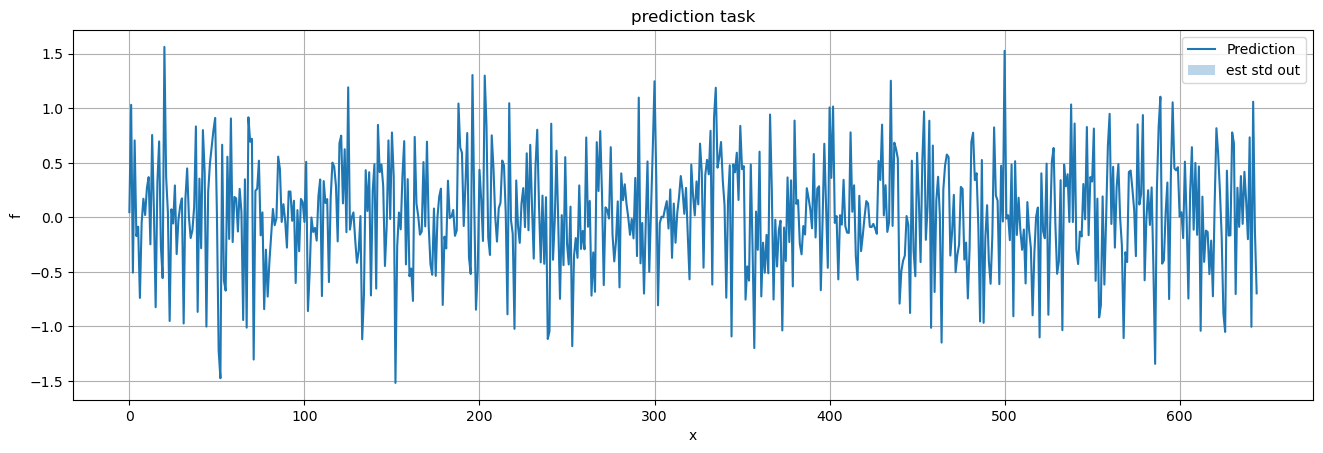

In [ ]:

data = np.load('hidden-test-prediction-submission-file.npz')
upast_test = data['upast'] #N by u[k-15],u[k-14],...,u[k-1]
thpast_test = data['thpast'] #N by y[k-15],y[k-14],...,y[k-1]
Xtest = np.concatenate([upast_test[:,15-nb:15], thpast_test[:,15-na:15]],axis=1)

Ypredict, Varpredict = BCM_predict(Xtest,reg_bcm)

np.savez('BCM-hidden-test-prediction-example-submission-file.npz', upast=upast_test, thpast=thpast_test, thnow=Ypredict)

quick_plot(range(len(Xtest)),Ypredict,Varpredict,'prediction task')


# Simulations task P.1

  0%|          | 0/6 [00:00<?, ?it/s]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(
/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(
/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(
/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(
/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted varian

validation mean prediction RMSE:  0.0035274798023367856
validation mean simulation RMSE:  0.04949094228944432


/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(


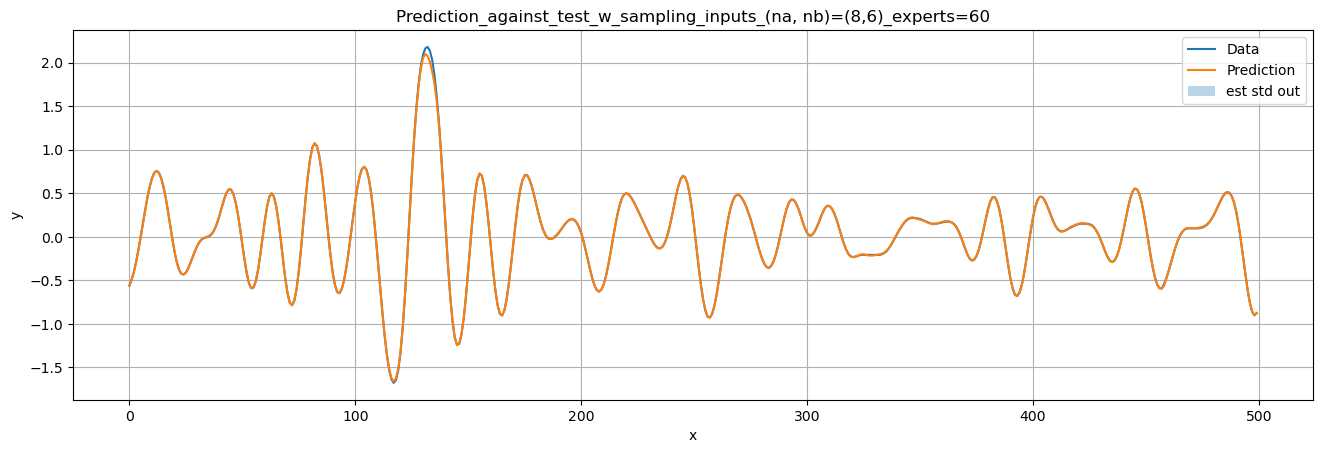

In [479]:

indices_pred = np.array(range(len(Xtest_target)))<500      #show on the graph on 500 points

part_range = np.array(range(500))


rms_sim = np.zeros(6)
rms_pred = np.zeros(6)

for k in tqdm(range(6)):
        X_val = Xtrain[(k*V):((k+1)*V),:]
        Y_val = Ytrain[(k*V):((k+1)*V)]
        u_val = u_target[(k*V):((k+1)*V)]
        th_val = th_target[(k*V):((k+1)*V)]

        reg_index = ((np.array(range(60))) < k*10) | ((np.array(range(60))) >= (k+1)*10)
        th_val_pred, var_val_pred = BCM_predict(X_val,reg_bcm[reg_index])

        th_val_sim, var_val_sim = simulation_IO_model_custom(simulate_handler, reg_bcm[reg_index], u_val, th_val, na, nb ,skip=50)
        

        if k==5: rms_sim[k] = np.mean((Y_val[:]-th_val_sim[max(na,nb):])**2)**0.5
        else: rms_sim[k] = np.mean((Y_val[:(V-max(na,nb))]-th_val_sim[max(na,nb):])**2)**0.5

        rms_pred[k] = np.mean((Y_val-th_val_pred)**2)**0.5

        
print("validation mean prediction RMSE: ", np.mean(rms_pred))
print("validation mean simulation RMSE: ", np.mean(rms_sim))

Ytest_pred, var_test_pred = predict_handler(Xtest_target) 
demonstrate_alternate(part_range, Ytest_target[indices_pred], Ytest_pred[indices_pred] , var_test_pred[indices_pred] , f"Prediction_against_test_w_sampling_inputs_(na, nb)=({na},{nb})_experts={p_bcm}")


# Simulation task P.2

In [22]:
data = np.load('hidden-test-simulation-submission-file.npz')
u_test = data['u']
th_test = data['th'] #only the first 50 values are filled the rest are zeros


def simulation_IO_model(f, reg, ulist, ylist, skip=50):
    
    upast = ulist[skip-nb:skip].tolist() #good initialization
    ypast = ylist[skip-na:skip].tolist()
    Y = ylist[:skip].tolist()
    var = []
    for u in tqdm(ulist[skip:]):
        x = np.concatenate([upast,ypast],axis=0)
        ypred, v = f(x,reg)
        var.append(v)
        Y.append(ypred)
        upast.append(u)
        upast.pop(0)
        ypast.append(ypred)
        ypast.pop(0)
    return np.array(Y), np.concat((np.zeros(max(na,nb)),np.array(var)))




In [23]:
skip = max(na,nb)


th_test_sim_target, var_test_sim_target = simulation_IO_model(simulate_handler, reg_bcm, u_test_target, th_test_target, skip=skip)


#skip1 = 50
#
#th_test_sim,  var_test_sim = simulation_IO_model(simulate_handler, reg_bcm, u_test, th_test, skip=skip1)
#
#assert len(th_test_sim)==len(th_test)
#np.savez('BCM-hidden-test-simulation-example-submission-file.npz', th=th_test_sim, u=u_test)



100%|██████████| 4992/4992 [02:17<00:00, 36.37it/s]


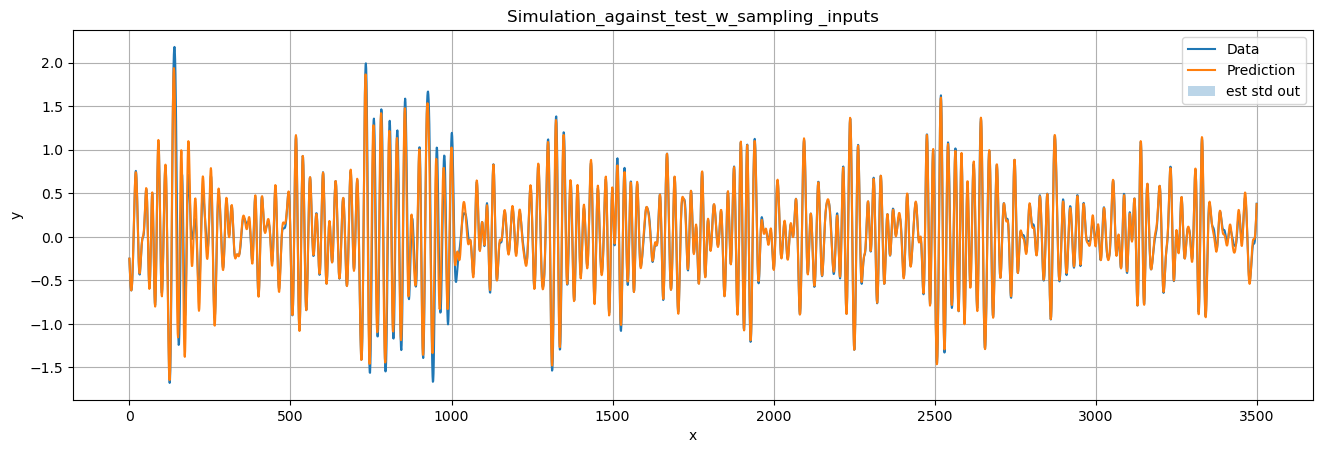

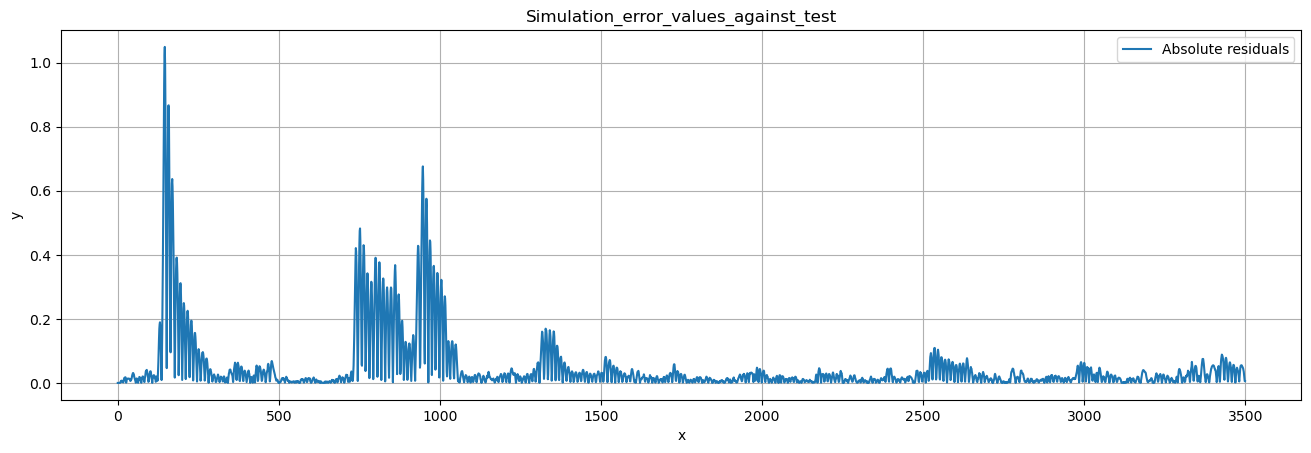

In [35]:
#print(len(th_train))
#print(len(full_range[:V]))

end = 3500

#demonstrate_alternate(full_range[:3500], th_test_target[:3500], th_test_sim_target[:3500], var_test_sim_target[:3500], f"Simulation_against_test_w_sampling _inputs_(na, nb)=({na},{nb})_experts={p_bcm}")
demonstrate_alternate(full_range[:end], th_test_target[:end], th_test_sim_target[:end], var_test_sim_target[:end], f"Simulation_against_test_w_sampling _inputs")
demonstrate(full_range[:end], np.abs(th_test_target[:end] - th_test_sim_target[:end]), "Absolute residuals", f"Simulation_error_values_against_test")

# Results

In [489]:

print('Test prediction errors:')
print('RMS:',  np.mean((Ytest_target-Ytest_pred)**2)**0.5,'radians')
print('RMS:',  np.mean((Ytest_target-Ytest_pred)**2)**0.5/(2*np.pi)*360,'degrees')
print('NRMS:', np.mean((Ytest_target-Ytest_pred)**2)**0.5/Ytrain.std()*100,'%')

print('Test simulation errors:')
print('RMS:',  np.mean((th_test_sim_target[skip:]-th_test_target[skip:])**2)**0.5,'radians')
print('RMS:',  np.mean((th_test_sim_target[skip:]-th_test_target[skip:])**2)**0.5/(2*np.pi)*360,'degrees')
print('NRMS:', np.mean((th_test_sim_target[skip:]-th_test_target[skip:])**2)**0.5/th_train.std()*100,'%')

Test prediction errors:
RMS: 0.005252466221738847 radians
RMS: 0.30094414654066154 degrees
NRMS: 1.110750238715908 %
Test simulation errors:
RMS: 0.08993697848785306 radians
RMS: 5.153009289512857 degrees
NRMS: 18.762774083114667 %
